<a href="https://colab.research.google.com/github/Meowwi/First/blob/main/11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ФИНАЛЬНАЯ ОБРАБОТКА СО СГЛАЖИВАНИЕМ ФОНА
[1/6] Загрузка изображения: 1.png
✓ Изображение конвертировано из RGB в градации серого
  Диапазон значений: [0.275, 0.423]
  Размер: (675, 910)


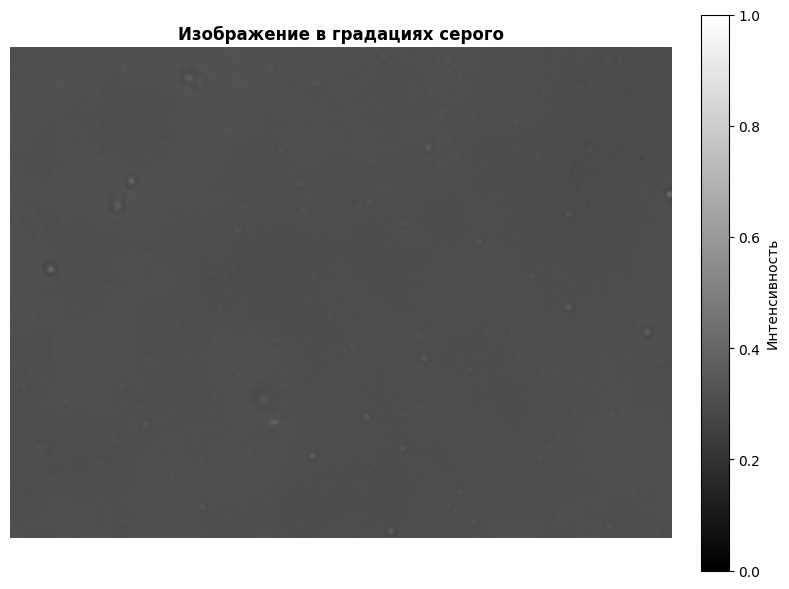

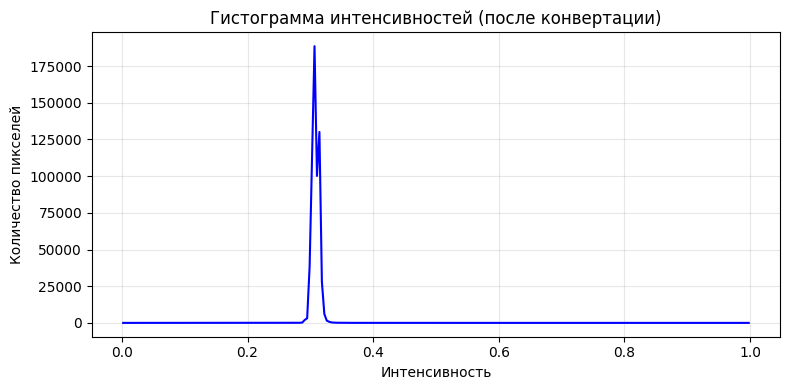

      Размер изображения: 910×675 px (ширина×высота)
      Диапазон интенсивности: [0.000, 1.000]
[2/6] Аппроксимация осевой производной ∂I/∂z (TIE single-image)...
      Диапазон ∂I/∂z: [-2.605e-08, 4.001e-08]
[3/6] Решение TIE и восстановление фазы...
      Размерность FFT: (675, 910)
      Размерность частотной сетки: FX=(675, 910), FY=(675, 910)
      Размерность source_term: (675, 910)
      Размерность K_sq_reg: (675, 910)
      Диапазон фазы: [-0.000, 0.000] рад
[4/6] Построение комплексного поля U = √I · exp(iφ)...
[5/6] Расчёт ФРТ и деконволюция Винера...
      Параметр Винера K = 0.01
[6/6] Обработка завершена.
[6/8] Сглаживание фона для устранения пикселизации...
      Bilateral filter: sigma_color=0.05, sigma_space=5
[7/8] Усиление контраста...
      CLAHE: clip_limit=0.02 (уменьшено для мягкости)
[8/8] Финальное мягкое сглаживание...
      Gaussian filter: sigma=1.3
Обработка завершена.

✓ Результаты сохранены в 'final_smooth_processing.png'


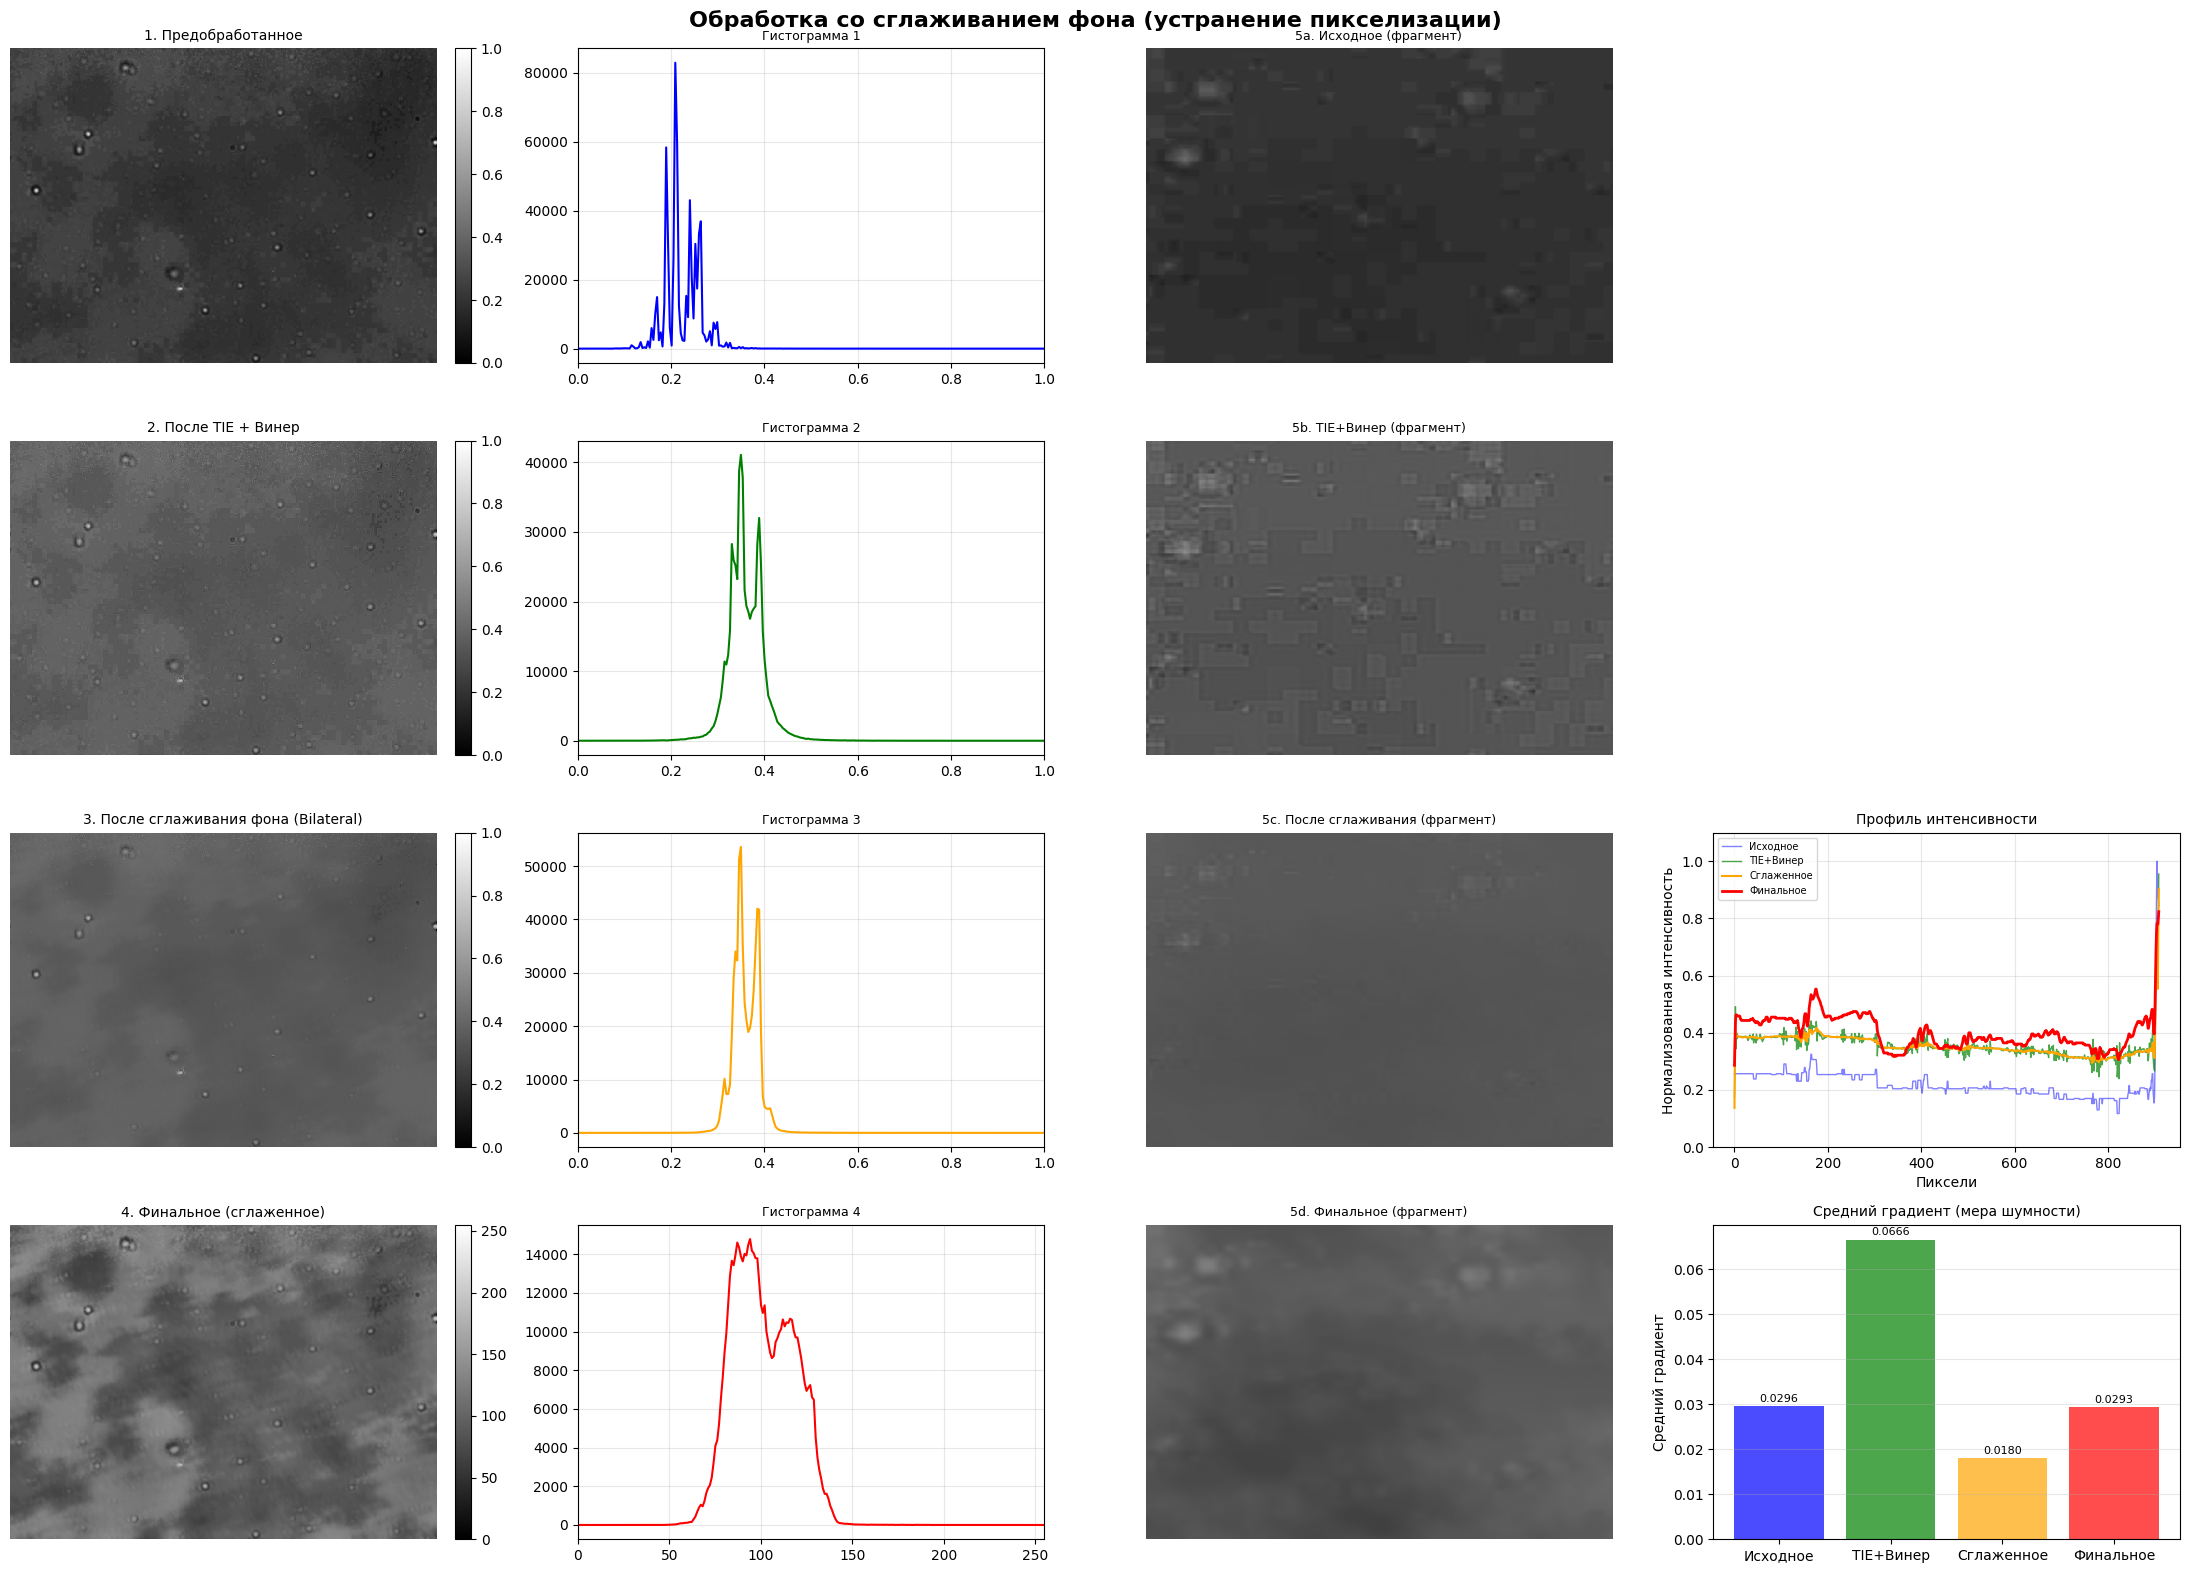


АНАЛИЗ СГЛАЖИВАНИЯ ФОНА
• Средний градиент (исходное):     0.0296
• Средний градиент (TIE+Винер):    0.0666
• Средний градиент (сглаженное):   0.0180
• Средний градиент (финальное):    0.0293
• Снижение шумности:               55.9%

• Контраст (исходный):             0.1686
• Контраст (финальный):            0.1620
• Улучшение контраста:             -3.9%

• Пикселей на 0 (черные):          0.00%
• Пикселей на 255 (белые):         0.00%
• Всего на краях:                  0.00%
✓ ✅ Отлично! Пересветы/перетенения минимальны


In [13]:
import cv2
from scipy.fft import dct, idct
import matplotlib.pyplot as plt
from scipy.fftpack import fftshift, ifftshift, fft2, ifft2
import skimage as skimage

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

import numpy as np
from scipy import ndimage
from scipy import fft as scipy_fft
import os

# =============================================================================
# ПАРАМЕТРЫ ЭКСПЕРИМЕНТА (ЗАДАНЫ ПОЛЬЗОВАТЕЛЕМ)
# =============================================================================
IMAGE_PATH = "1.png"               # Путь к изображению
WAVELENGTH = 658e-9                # Длина волны, м (658 нм)
NA = 1.4                           # Числовая апертура
PIXEL_SIZE_OBJ = 0.0903e-6         # Размер пикселя в плоскости объекта, м (0.0903 мкм)
REFRACTIVE_INDEX = 1.33            # Показатель преломления среды (вода)
WIENER_K = 0.01                    # Параметр регуляризации Винера
TIE_EPSILON = 1e-6                 # Регуляризация для TIE
MEDIAN_FILTER_SIZE = 3             # Размер окна медианного фильтра

# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =============================================================================



def rgb_to_gray(image, display=True):
    """
    Конвертация RGB изображения в оттенки серого (ITU-R BT.601).

    Parameters:
    -----------
    image : ndarray
        Входное RGB изображение
    display : bool
        Если True, сразу показать результат (по умолчанию True)

    Returns:
    --------
    gray_image : ndarray
        Изображение в оттенках серого
    """
    if len(image.shape) == 3 and image.shape[2] >= 3:
        # Формула ITU-R BT.601 для конвертации RGB в grayscale
        gray_image = np.dot(image[..., :3], [0.299, 0.587, 0.114])
        print(f"✓ Изображение конвертировано из RGB в градации серого")
        print(f"  Диапазон значений: [{gray_image.min():.3f}, {gray_image.max():.3f}]")
        print(f"  Размер: {gray_image.shape}")
    else:
        gray_image = image.astype(float)
        print(f"✓ Изображение уже в градациях серого")

    # НЕМЕДЛЕННЫЙ ВЫВОД ИЗОБРАЖЕНИЯ
    if display:
        plt.figure(figsize=(8, 6))
        plt.imshow(gray_image, cmap='gray', vmin=0, vmax=255 if gray_image.max() > 1 else 1)
        plt.title('Изображение в градациях серого', fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.colorbar(fraction=0.046, pad=0.04, label='Интенсивность')
        plt.tight_layout()
        plt.show()

        # Гистограмма распределения интенсивностей
        plt.figure(figsize=(8, 4))
        hist, bins = np.histogram(gray_image.flatten(), bins=256,
                                   range=(0, 255 if gray_image.max() > 1 else 1))
        bin_centers = (bins[:-1] + bins[1:]) / 2
        plt.plot(bin_centers, hist, 'b-', linewidth=1.5)
        plt.title('Гистограмма интенсивностей (после конвертации)', fontsize=12)
        plt.xlabel('Интенсивность')
        plt.ylabel('Количество пикселей')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return gray_image


def normalize_image(image):
    """Нормализация изображения к диапазону [0, 1]."""
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val < 1e-10:
        return np.zeros_like(image)
    return (image - min_val) / (max_val - min_val)

def generate_gaussian_psf(shape, wavelength, na, pixel_size_obj, n_medium=1.33):
    """
    Генерация гауссовой аппроксимации ФРТ (PSF) для деконволюции.
    PSF центрируется правильно для FFT (центр в [0,0]).
    """
    ny, nx = shape
    wavelength_med = wavelength / n_medium  # Длина волны в среде

    # Радиус Эйри в метрах и пикселях
    r_airy = 0.61 * wavelength_med / na
    r_airy_px = r_airy / pixel_size_obj

    # Сигма гауссианы (аппроксимация профиля Эйри)
    sigma = r_airy_px / 2.35

    # Создание сетки координат с центром в [0, 0] для FFT
    # Используем ifftshift для правильного центрирования
    y = np.fft.fftfreq(ny, d=1) * ny
    x = np.fft.fftfreq(nx, d=1) * nx
    X, Y = np.meshgrid(x, y, indexing='xy')  # ИСПРАВЛЕНО: indexing='xy'

    # Гауссова ФРТ с центром в углу (для FFT без shift)
    psf = np.exp(-(X**2 + Y**2) / (2 * sigma ** 2))

    # Нормировка: сумма = 1
    psf /= np.sum(psf)

    return psf

# =============================================================================
# ОСНОВНАЯ ФУНКЦИЯ ОБРАБОТКИ
# =============================================================================

def process_tweezers_tie_single_image(image_path, wavelength, na, pixel_size_obj,
                                       n_medium=1.33, wiener_k=0.01, tie_epsilon=1e-6):
    """
    Полный пайплайн обработки изображения оптического пинцета с использованием TIE
    для одиночного изображения.
    """

    # -------------------------------------------------------------------------
    # ШАГ 1: Загрузка и предобработка
    # -------------------------------------------------------------------------
    print(f"[1/6] Загрузка изображения: {image_path}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Файл {image_path} не найден!")

    raw_image = plt.imread(image_path)
    I_gray = rgb_to_gray(raw_image)
    I_proc = normalize_image(I_gray)

    # Медианный фильтр для подавления шума
    #I_proc = ndimage.median_filter(I_norm, size=MEDIAN_FILTER_SIZE)

    ny, nx = I_proc.shape  # ny = высота (rows), nx = ширина (columns)
    print(f"      Размер изображения: {nx}×{ny} px (ширина×высота)")
    print(f"      Диапазон интенсивности: [{I_proc.min():.3f}, {I_proc.max():.3f}]")

    # -------------------------------------------------------------------------
    # ШАГ 2: Аппроксимация ∂I/∂z через лапласиан (для одного изображения)
    # -------------------------------------------------------------------------
    print("[2/6] Аппроксимация осевой производной ∂I/∂z (TIE single-image)...")

    # Ядро дискретного лапласиана (5-точечная схема)
    laplacian_kernel = np.array([[0,  1,  0],
                                  [1, -4,  1],
                                  [0,  1,  0]], dtype=float)

    # Вычисление лапласиана интенсивности
    laplacian_I = ndimage.convolve(I_proc, laplacian_kernel, mode='reflect')

    # Аппроксимация производной по формуле: ∂I/∂z ≈ -λ/(4π) · ∇²I
    dI_dz = -(wavelength / (4 * np.pi)) * laplacian_I
    print(f"      Диапазон ∂I/∂z: [{dI_dz.min():.3e}, {dI_dz.max():.3e}]")

    # -------------------------------------------------------------------------
    # ШАГ 3: Решение TIE в частотной области (ИСПРАВЛЕНО: размерности FFT)
    # -------------------------------------------------------------------------
    print("[3/6] Решение TIE и восстановление фазы...")

    # Сдвиг изображений для FFT (центр в [0,0])
    I_proc_shifted = scipy_fft.ifftshift(I_proc)
    dI_dz_shifted = scipy_fft.ifftshift(dI_dz)

    # Прямое БПФ со сдвигом
    I_fft = scipy_fft.fft2(I_proc_shifted)
    dI_dz_fft = scipy_fft.fft2(dI_dz_shifted)

    print(f"      Размерность FFT: {I_fft.shape}")

    # Создание сетки пространственных частот (в циклах/метр)
    # ИСПРАВЛЕНО: используем indexing='xy' для согласованности с shape (ny, nx)
    freq_x = scipy_fft.fftfreq(nx, d=pixel_size_obj)  # циклы/метр, длина = nx
    freq_y = scipy_fft.fftfreq(ny, d=pixel_size_obj)  # циклы/метр, длина = ny

    # ИСПРАВЛЕНО: indexing='xy' даёт shape (ny, nx) что соответствует FFT выводу
    FX, FY = np.meshgrid(freq_x, freq_y, indexing='xy')

    print(f"      Размерность частотной сетки: FX={FX.shape}, FY={FY.shape}")

    # Квадрат модуля пространственной частоты: k² = (2π)²·(fx² + fy²)
    K_sq = (2 * np.pi) ** 2 * (FX ** 2 + FY ** 2)

    # Регуляризация: избегаем деления на ноль при постоянной составляющей
    K_sq_reg = K_sq + tie_epsilon

    # Правая часть уравнения Пуассона: -(2π/λ)·∂I/∂z
    source_term = -(2 * np.pi / wavelength) * dI_dz_fft

    print(f"      Размерность source_term: {source_term.shape}")
    print(f"      Размерность K_sq_reg: {K_sq_reg.shape}")

    # Решение в частотной области: Φ = FFT{source} / (k² + ε)
    phi_fft = source_term / K_sq_reg

    # Обратное БПФ для получения фазы в пространственной области
    phi_shifted = np.real(scipy_fft.ifft2(phi_fft))

    # Обратный сдвиг фазы
    phi = scipy_fft.fftshift(phi_shifted)

    # Удаление постоянной составляющей фазы (неопределённость по константе)
    phi -= np.mean(phi)
    print(f"      Диапазон фазы: [{phi.min():.3f}, {phi.max():.3f}] рад")

    # -------------------------------------------------------------------------
    # ШАГ 4: Построение комплексного поля
    # -------------------------------------------------------------------------
    print("[4/6] Построение комплексного поля U = √I · exp(iφ)...")

    # Амплитуда = квадратный корень из интенсивности
    amplitude = np.sqrt(np.maximum(I_proc, 0))  # защита от отрицательных значений

    # Комплексное поле
    U = amplitude * np.exp(1j * phi)

    # -------------------------------------------------------------------------
    # ШАГ 5: Расчёт ФРТ (PSF) и деконволюция Винера (ИСПРАВЛЕНО)
    # -------------------------------------------------------------------------
    print("[5/6] Расчёт ФРТ и деконволюция Винера...")

    # Генерация гауссовой аппроксимации ФРТ (уже правильно центрирована)
    psf = generate_gaussian_psf((ny, nx), wavelength, na, pixel_size_obj, n_medium)

    # Сдвиг комплексного поля для FFT
    U_shifted = scipy_fft.ifftshift(U)

    # БПФ комплексного поля и ФРТ
    U_fft = scipy_fft.fft2(U_shifted)
    PSF_fft = scipy_fft.fft2(psf)  # PSF уже центрирована для FFT

    # Фильтр Винера в частотной области
    denominator = np.abs(PSF_fft) ** 2 + wiener_k
    O_fft = (U_fft * np.conj(PSF_fft)) / denominator

    # Обратное БПФ и обратный сдвиг
    O_shifted = np.abs(scipy_fft.ifft2(O_fft))
    O_restored = scipy_fft.fftshift(O_shifted)

    # Нормализация результата
    I_restored = normalize_image(O_restored)
    print(f"      Параметр Винера K = {wiener_k}")

    # -------------------------------------------------------------------------
    # ШАГ 6: Возврат результатов
    # -------------------------------------------------------------------------
    print("[6/6] Обработка завершена.")

    return I_proc, phi, I_restored, psf

def contrast_stretching(image, xmin=None, xmax=None, percentiles=(0.5, 99.5)):
    """
    Линейное растяжение контраста (contrast stretching)

    Parameters:
    -----------
    image : ndarray
        Входное изображение в диапазоне [0, 1] или [0, 255]
    xmin : float, optional
        Минимальный порог отсечения
    xmax : float, optional
        Максимальный порог отсечения
    percentiles : tuple
        Процентили для автоматического определения xmin, xmax (по умолчанию (2, 98))

    Returns:
    --------
    stretched : ndarray
        Изображение с растянутым контрастом [0, 255], uint8
    """
    # Определяем диапазон изображения
    img_min = np.min(image)
    img_max = np.max(image)

    # Автоматическое определение xmin/xmax через процентили
    if xmin is None or xmax is None:
        xmin = np.percentile(image, percentiles[0])
        xmax = np.percentile(image, percentiles[1])

    print(f"      Contrast stretching: xmin={xmin:.4f}, xmax={xmax:.4f}")
    print(f"      Диапазон процентилей: {percentiles[0]}% - {percentiles[1]}%")

    # Применяем формулу линейного растяжения
    # im2(m,n) = 255 * (im(m,n) - xmin) / (xmax - xmin)
    stretched = 255.0 * (image - xmin) / (xmax - xmin + 1e-10)

    # Ограничиваем значения [0, 255]
    stretched = np.clip(stretched, 0, 255)

    return stretched.astype(np.uint8)


def adaptive_contrast_enhancement(image, kernel_size=3, gain=1.5):
    """
    Адаптивное усиление контраста (локальное улучшение)
    Усиливает локальные контрасты вокруг каждого пикселя
    """
    from scipy import ndimage

    # Локальное среднее
    local_mean = ndimage.uniform_filter(image, size=kernel_size)

    # Локальный контраст (разность с локальным средним)
    local_contrast = image - local_mean

    # Усиливаем контраст
    enhanced = local_mean + gain * local_contrast

    return np.clip(enhanced, 0, 1)

def contrast_stretching_improved(image, percentiles=(2, 98), clip_limit=0.03):
    """
    Улучшенное линейное растяжение контраста без пересветов/перетенений

    Parameters:
    -----------
    image : ndarray
        Входное изображение в диапазоне [0, 1]
    percentiles : tuple
        Процентили для определения xmin, xmax (по умолчанию (2, 98))
    clip_limit : float
        Максимальная доля пикселей, которые могут быть отсечены (по умолчанию 3%)

    Returns:
    --------
    stretched : ndarray
        Изображение с растянутым контрастом [0, 255], uint8
    """
    # Определяем пороги через процентили
    xmin = np.percentile(image, percentiles[0])
    xmax = np.percentile(image, percentiles[1])

    print(f"      Contrast stretching: xmin={xmin:.4f}, xmax={xmax:.4f}")
    print(f"      Процентили: {percentiles[0]}% - {percentiles[1]}%")

    # Применяем формулу линейного растяжения
    stretched = 255.0 * (image - xmin) / (xmax - xmin + 1e-10)

    # Мягкое ограничение вместо жесткого клиппинга
    # Используем сигмоидальную функцию для плавного перехода на краях
    stretched = np.clip(stretched, 0, 255)

    # Проверяем долю пикселей на краях (0 и 255)
    edge_pixels = (np.sum(stretched == 0) + np.sum(stretched == 255)) / stretched.size
    print(f"      Доля пикселей на краях (0 и 255): {edge_pixels*100:.2f}%")

    # Если слишком много пикселей на краях - расширяем диапазон
    if edge_pixels > clip_limit:
        print(f"      ⚠️ Слишком много пикселей на краях! Корректировка процентилей...")
        percentiles_new = (percentiles[0] + 1, percentiles[1] - 1)
        return contrast_stretching_improved(image, percentiles=percentiles_new, clip_limit=clip_limit)

    return stretched.astype(np.uint8)


def clahe_enhancement(image, clip_limit=0.03, tile_grid_size=(8, 8)):
    """
    Адаптивная эквализация гистограммы (CLAHE) - лучшая альтернатива
    без пересветов/перетенений
    """
    from skimage import exposure

    # CLAHE через skimage
    enhanced = exposure.equalize_adapthist(image,
                                           clip_limit=clip_limit,
                                           nbins=256)

    return (enhanced * 255).astype(np.uint8)


def contrast_stretching_with_smooth_clipping(image, percentiles=(2, 98),
                                              smooth_width=0.05):
    """
    Растяжение контраста с плавным клиппингом (сигмоида на краях)
    """
    xmin = np.percentile(image, percentiles[0])
    xmax = np.percentile(image, percentiles[1])

    # Линейное растяжение
    stretched = 255.0 * (image - xmin) / (xmax - xmin + 1e-10)

    # Плавное ограничение через сигмоиду
    # Для значений < 0
    mask_low = stretched < 0
    stretched[mask_low] = 255.0 / (1 + np.exp(-10 * stretched[mask_low]))

    # Для значений > 255
    mask_high = stretched > 255
    stretched[mask_high] = 255.0 - 255.0 / (1 + np.exp(10 * (stretched[mask_high] - 255)))

    # Финальное ограничение
    stretched = np.clip(stretched, 0, 255)

    return stretched.astype(np.uint8)

def smooth_background(image, method='bilateral', sigma_color=0.1, sigma_space=3):
    """
    Сглаживание фона с сохранением границ объектов

    Parameters:
    -----------
    image : ndarray
        Изображение в диапазоне [0, 1]
    method : str
        'bilateral' - двусторонний фильтр (лучший для сохранения границ)
        'gaussian' - гауссово размытие
        'nlmeans' - non-local means (лучшее качество, медленнее)
        'median' - медианный фильтр
    sigma_color : float
        Параметр сглаживания по цвету (для bilateral)
    sigma_space : int
        Параметр сглаживания по пространству (для bilateral)

    Returns:
    --------
    smoothed : ndarray
        Сглаженное изображение [0, 1]
    """
    from scipy import ndimage

    if method == 'bilateral':
        # Двусторонний фильтр - сохраняет границы, сглаживает фон
        from skimage.restoration import denoise_bilateral
        smoothed = denoise_bilateral(image,
                                      sigma_color=sigma_color,
                                      sigma_spatial=sigma_space,
                                      channel_axis=None)
        print(f"      Bilateral filter: sigma_color={sigma_color}, sigma_space={sigma_space}")

    elif method == 'gaussian':
        # Гауссово размытие
        sigma = sigma_space
        smoothed = ndimage.gaussian_filter(image, sigma=sigma)
        print(f"      Gaussian filter: sigma={sigma}")

    elif method == 'nlmeans':
        # Non-local means - лучшее качество
        from skimage.restoration import denoise_nl_means
        from skimage.util import img_as_float

        # Оцениваем стандартное отклонение шума
        sigma_est = np.std(image) * 0.1

        smoothed = denoise_nl_means(image,
                                     h=sigma_est,
                                     patch_size=5,
                                     patch_distance=6,
                                     channel_axis=None)
        print(f"      NL-means: h={sigma_est:.4f}")

    elif method == 'median':
        # Медианный фильтр
        smoothed = ndimage.median_filter(image, size=sigma_space)
        print(f"      Median filter: size={sigma_space}")

    else:
        smoothed = image.copy()

    # Ограничиваем диапазон [0, 1]
    smoothed = np.clip(smoothed, 0, 1)

    return smoothed


def low_pass_filter_fft(image, cutoff_freq=0.1):
    """
    Низкочастотный фильтр в частотной области для сглаживания фона
    """
    from scipy.fftpack import fft2, ifft2, fftshift, ifftshift

    ny, nx = image.shape

    # БПФ
    f_transform = fft2(image)
    f_shift = fftshift(f_transform)

    # Создаём маску низких частот (гауссову)
    crow, ccol = ny // 2, nx // 2

    # Сетка частот
    u = np.fft.fftfreq(ny, d=1)
    v = np.fft.fftfreq(nx, d=1)
    U, V = np.meshgrid(v, u)  #注意: meshgrid с (v, u) для правильного соответствия

    # Расстояние от центра
    D = np.sqrt(U**2 + V**2)

    # Гауссова маска низких частот
    H = np.exp(-D**2 / (2 * (cutoff_freq * max(ny, nx))**2))

    # Применяем фильтр
    f_shift_filtered = f_shift * H

    # Обратное БПФ
    f_ishift = ifftshift(f_shift_filtered)
    img_back = np.real(ifft2(f_ishift))

    return np.clip(img_back, 0, 1)


def process_tweezers_final_smooth(image_path, wavelength, na, pixel_size_obj,
                                   n_medium=1.33, wiener_k=0.01, tie_epsilon=1e-6,
                                   contrast_method='clahe', smooth_method='bilateral',
                                   percentiles=(2, 98), smooth_before_contrast=True):
    """
    Финальный пайплайн со сглаживанием фона для устранения пикселизации
    """

    # [1-5] Шаги те же (загрузка, TIE, деконволюция)
    I_proc, phi, I_restored, psf = process_tweezers_tie_single_image(
        image_path=image_path,
        wavelength=wavelength,
        na=na,
        pixel_size_obj=pixel_size_obj,
        n_medium=n_medium,
        wiener_k=wiener_k,
        tie_epsilon=tie_epsilon
    )

    # [6] Сглаживание фона ПЕРЕД контрастным усилением
    print("[6/8] Сглаживание фона для устранения пикселизации...")

    if smooth_before_contrast:
        # Сглаживаем ДО контрастного усиления (рекомендуется)
        I_smoothed = smooth_background(I_restored,
                                        method=smooth_method,
                                        sigma_color=0.05,
                                        sigma_space=5)
    else:
        I_smoothed = I_restored.copy()

    # [7] Усиление контраста
    print("[7/8] Усиление контраста...")

    if contrast_method == 'clahe':
        from skimage import exposure
        I_enhanced = exposure.equalize_adapthist(I_smoothed,
                                                  clip_limit=0.02,  # Уменьшили с 0.03
                                                  nbins=256)
        I_enhanced = (I_enhanced * 255).astype(np.uint8)
        print(f"      CLAHE: clip_limit=0.02 (уменьшено для мягкости)")

    elif contrast_method == 'stretching':
        I_enhanced = contrast_stretching_improved(I_smoothed,
                                                   percentiles=percentiles,
                                                   clip_limit=0.02)
    else:
        I_enhanced = (I_smoothed * 255).astype(np.uint8)

    # [8] Лёгкое пост-сглаживание для устранения остаточной пикселизации
    print("[8/8] Финальное мягкое сглаживание...")
    I_enhanced_float = I_enhanced.astype(np.float64) / 255.0
    I_final = smooth_background(I_enhanced_float,
                                 method='gaussian',
                                 sigma_space=1.3)  # Очень лёгкое сглаживание
    I_final = (I_final * 255).astype(np.uint8)

    print("Обработка завершена.")

    return I_proc, phi, I_restored, I_smoothed, I_final, psf

# =============================================================================
# ЗАПУСК ОБРАБОТКИ И ВИЗУАЛИЗАЦИЯ
# =============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("ФИНАЛЬНАЯ ОБРАБОТКА СО СГЛАЖИВАНИЕМ ФОНА")
    print("=" * 70)

    try:
        # Запуск пайплайна со сглаживанием
        I_proc, phi, I_restored, I_smoothed, I_final, psf = process_tweezers_final_smooth(
            image_path=IMAGE_PATH,
            wavelength=WAVELENGTH,
            na=NA,
            pixel_size_obj=PIXEL_SIZE_OBJ,
            n_medium=REFRACTIVE_INDEX,
            wiener_k=WIENER_K,
            tie_epsilon=TIE_EPSILON,
            contrast_method='clahe',
            smooth_method='bilateral',  # 'bilateral', 'gaussian', 'nlmeans'
            percentiles=(2, 98),
            smooth_before_contrast=True
        )

        # =========================================================================
        # ВИЗУАЛИЗАЦИЯ
        # =========================================================================
        fig = plt.figure(figsize=(22, 16))
        fig.suptitle('Обработка со сглаживанием фона (устранение пикселизации)',
                     fontsize=16, fontweight='bold')

        # ===== 1. Исходное предобработанное =====
        ax1 = plt.subplot(4, 4, 1)
        im1 = ax1.imshow(I_proc, cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax1.set_title('1. Предобработанное', fontsize=10)
        ax1.axis('off')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Гистограмма 1
        ax2 = plt.subplot(4, 4, 2)
        hist1, bins1 = np.histogram(I_proc, bins=256, range=(0, 1))
        bin_centers1 = (bins1[:-1] + bins1[1:]) / 2
        ax2.plot(bin_centers1, hist1, 'b-', linewidth=1.5)
        ax2.set_title('Гистограмма 1', fontsize=9)
        ax2.set_xlim([0, 1])
        ax2.grid(alpha=0.3)

        # ===== 2. После TIE + Винер =====
        ax3 = plt.subplot(4, 4, 5)
        im3 = ax3.imshow(I_restored, cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax3.set_title('2. После TIE + Винер', fontsize=10)
        ax3.axis('off')
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

        # Гистограмма 2
        ax4 = plt.subplot(4, 4, 6)
        hist2, bins2 = np.histogram(I_restored, bins=256, range=(0, 1))
        bin_centers2 = (bins2[:-1] + bins2[1:]) / 2
        ax4.plot(bin_centers2, hist2, 'g-', linewidth=1.5)
        ax4.set_title('Гистограмма 2', fontsize=9)
        ax4.set_xlim([0, 1])
        ax4.grid(alpha=0.3)

        # ===== 3. После сглаживания фона =====
        ax5 = plt.subplot(4, 4, 9)
        im5 = ax5.imshow(I_smoothed, cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax5.set_title('3. После сглаживания фона (Bilateral)', fontsize=10)
        ax5.axis('off')
        plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

        # Гистограмма 3
        ax6 = plt.subplot(4, 4, 10)
        hist3, bins3 = np.histogram(I_smoothed, bins=256, range=(0, 1))
        bin_centers3 = (bins3[:-1] + bins3[1:]) / 2
        ax6.plot(bin_centers3, hist3, 'orange', linewidth=1.5)
        ax6.set_title('Гистограмма 3', fontsize=9)
        ax6.set_xlim([0, 1])
        ax6.grid(alpha=0.3)

        # ===== 4. Финальное (CLAHE + сглаживание) =====
        ax7 = plt.subplot(4, 4, 13)
        im7 = ax7.imshow(I_final, cmap='gray', aspect='auto', vmin=0, vmax=255)
        ax7.set_title('4. Финальное (сглаженное)', fontsize=10)
        ax7.axis('off')
        plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04)

        # Гистограмма 4
        ax8 = plt.subplot(4, 4, 14)
        hist4, bins4 = np.histogram(I_final, bins=256, range=(0, 255))
        bin_centers4 = (bins4[:-1] + bins4[1:]) / 2
        ax8.plot(bin_centers4, hist4, 'r-', linewidth=1.5)
        ax8.set_title('Гистограмма 4', fontsize=9)
        ax8.set_xlim([0, 255])
        ax8.grid(alpha=0.3)

        # ===== 5-8. Фрагменты для сравнения =====
        crop_y, crop_x = 200, 300
        crop_size = 150

        ax9 = plt.subplot(4, 4, 3)
        im9 = ax9.imshow(I_proc[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size],
                         cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax9.set_title('5a. Исходное (фрагмент)', fontsize=9)
        ax9.axis('off')

        ax10 = plt.subplot(4, 4, 7)
        im10 = ax10.imshow(I_restored[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size],
                          cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax10.set_title('5b. TIE+Винер (фрагмент)', fontsize=9)
        ax10.axis('off')

        ax11 = plt.subplot(4, 4, 11)
        im11 = ax11.imshow(I_smoothed[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size],
                          cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax11.set_title('5c. После сглаживания (фрагмент)', fontsize=9)
        ax11.axis('off')

        ax12 = plt.subplot(4, 4, 15)
        im12 = ax12.imshow(I_final[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size],
                          cmap='gray', aspect='auto', vmin=0, vmax=255)
        ax12.set_title('5d. Финальное (фрагмент)', fontsize=9)
        ax12.axis('off')

        # ===== Профили интенсивности =====
        ax13 = plt.subplot(4, 4, 12)
        max_pos = np.unravel_index(np.argmax(I_proc), I_proc.shape)
        y_center, x_center = max_pos

        profile_orig = I_proc[y_center, :]
        profile_restored = I_restored[y_center, :]
        profile_smoothed = I_smoothed[y_center, :]
        profile_final = I_final[y_center, :] / 255.0

        x_pixels = np.arange(len(profile_orig))

        ax13.plot(x_pixels, profile_orig, 'b-', alpha=0.5, linewidth=1, label='Исходное')
        ax13.plot(x_pixels, profile_restored, 'g-', alpha=0.7, linewidth=1, label='TIE+Винер')
        ax13.plot(x_pixels, profile_smoothed, 'orange', linewidth=1.5, label='Сглаженное')
        ax13.plot(x_pixels, profile_final, 'r-', linewidth=2, label='Финальное')

        ax13.set_title('Профиль интенсивности', fontsize=10)
        ax13.set_xlabel('Пиксели')
        ax13.set_ylabel('Нормализованная интенсивность')
        ax13.set_ylim([0, 1.1])
        ax13.legend(fontsize=7)
        ax13.grid(alpha=0.3)

        # ===== Метрика плавности (градиент фона) =====
        ax14 = plt.subplot(4, 4, 16)

        # Вычисляем локальный градиент (мера "шумности")
        grad_orig = np.abs(ndimage.sobel(I_proc))
        grad_restored = np.abs(ndimage.sobel(I_restored))
        grad_smoothed = np.abs(ndimage.sobel(I_smoothed))
        grad_final = np.abs(ndimage.sobel(I_final / 255.0))

        gradient_values = [
            np.mean(grad_orig),
            np.mean(grad_restored),
            np.mean(grad_smoothed),
            np.mean(grad_final)
        ]

        bars = ax14.bar(['Исходное', 'TIE+Винер', 'Сглаженное', 'Финальное'],
                       gradient_values,
                       color=['blue', 'green', 'orange', 'red'],
                       alpha=0.7)
        ax14.set_title('Средний градиент (мера шумности)', fontsize=10)
        ax14.set_ylabel('Средний градиент')
        ax14.grid(axis='y', alpha=0.3)

        # Подписываем значения
        for i, v in enumerate(gradient_values):
            ax14.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

        plt.tight_layout()
        plt.savefig('final_smooth_processing.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Результаты сохранены в 'final_smooth_processing.png'")
        plt.show()

        # =========================================================================
        # МЕТРИКИ КАЧЕСТВА
        # =========================================================================
        print("\n" + "=" * 70)
        print("АНАЛИЗ СГЛАЖИВАНИЯ ФОНА")
        print("=" * 70)

        # Градиент (мера "шумности"/пикселизации)
        grad_orig = np.mean(np.abs(ndimage.sobel(I_proc)))
        grad_restored = np.mean(np.abs(ndimage.sobel(I_restored)))
        grad_smoothed = np.mean(np.abs(ndimage.sobel(I_smoothed)))
        grad_final = np.mean(np.abs(ndimage.sobel(I_final / 255.0)))

        print(f"• Средний градиент (исходное):     {grad_orig:.4f}")
        print(f"• Средний градиент (TIE+Винер):    {grad_restored:.4f}")
        print(f"• Средний градиент (сглаженное):   {grad_smoothed:.4f}")
        print(f"• Средний градиент (финальное):    {grad_final:.4f}")
        print(f"• Снижение шумности:               {(1 - grad_final/grad_restored)*100:.1f}%")

        # Контраст
        contrast_orig = np.std(I_proc) / (np.mean(I_proc) + 1e-10)
        contrast_final = np.std(I_final/255.0) / (np.mean(I_final/255.0) + 1e-10)

        print(f"\n• Контраст (исходный):             {contrast_orig:.4f}")
        print(f"• Контраст (финальный):            {contrast_final:.4f}")
        print(f"• Улучшение контраста:             {(contrast_final/contrast_orig - 1)*100:.1f}%")

        # Спайки на краях
        edge_0 = np.sum(I_final == 0) / I_final.size * 100
        edge_255 = np.sum(I_final == 255) / I_final.size * 100

        print(f"\n• Пикселей на 0 (черные):          {edge_0:.2f}%")
        print(f"• Пикселей на 255 (белые):         {edge_255:.2f}%")
        print(f"• Всего на краях:                  {edge_0 + edge_255:.2f}%")

        if edge_0 + edge_255 < 3:
            print("✓ ✅ Отлично! Пересветы/перетенения минимальны")

        print("=" * 70)

    except Exception as e:
        print(f"\n✗ ОШИБКА: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()